# Anomaly model

Forward model with an embedded rectangular anomaly (eps_r = 20) in a two-layer background.

The background reference is the Evert two-layer solution (no anomaly). The difference between the anomaly and background responses is the target signature.

In [6]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── locate master\ from examples\<name>\ (two levels up) ─────────────────
MASTER = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))


# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, all_errors, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


---
## Paths

In [7]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER)
print('exec     :', paths.exec_path())


master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

Same background as the two-layered example, plus a `BoxAnomaly` with eps_r = 20 buried between z = -0.9 m and z = -0.5 m.

In [8]:
f    = 100e6
wave = 3e8 / f

BASE_DIR = os.path.join(MASTER, 'elfe3D_GPR')

survey = GPRSurvey.build(
    experiment_name = 'AnAir',
    base_dir        = BASE_DIR,

    # Domain — same as two-layered
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-1.0 - wave/10/3, wave/10],

    # Materials — air + 2 earth layers (same background as two-layered)
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [1.0,    wave/10/3],
    layer_eps_r       = [4.0,    9.0],
    layer_sigma       = [1e-4,   1e-3],
    layer_mu_r        = [1.0,    1.0],
    layer_sigma_m     = [0.0,    0.0],

    # Anomaly — all three coordinate tuples + properties required together
    anomaly_x          = (0,        wave/8),
    anomaly_y          = (-wave/20, wave/20),
    anomaly_z          = (-0.9,     -0.5),
    anomaly_properties = (20, 1e-4, 1.0, 0.0),   # (eps_r, sigma, mu_r, sigma_m)

    # Source
    ricker_central_f    = f,
    num_points_per_range = 1,
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],
    m                   = 5,

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 12,
)

survey.generate()
print('poly :', survey.io.poly_file)


odepths: [0.0625, 0.03125, 0.020833333333333332]
Source antenna length: 0.0005 m
Receiver antenna depth: -0.000125 m
[0.0, -1.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_AnAir.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_AnAir.poly


---
## 2 — Mesh with TetGen

In [9]:
run_tetgen(paths, survey.io.poly_file)

── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_AnAir.poly

Opening GPR_model_AnAir.poly.
Delaunizing vertices...
Delaunay seconds:  0.002763
Creating surface mesh ...
Surface mesh seconds:  0.001079
Constrained Delaunay...
Constrained Delaunay seconds:  0.001936
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000176
Refining mesh...
Refinement seconds:  1.15997
Optimizing mesh...
Optimization seconds:  0.051652

Writing GPR_model_AnAir.1.node.
Writing GPR_model_AnAir.1.ele.
Writing GPR_model_AnAir.1.face.
Writing GPR_model_AnAir.1.edge.
Writing GPR_model_AnAir.1.vtk.
Writing GPR_model_AnAir.1.neigh.

Output seconds:  1.04895
Total running seconds:  2.26659

Statistics:

  Input points: 250
  Input facets: 133
  Input segments: 381
  Input holes: 0
  Input regions: 46

  Mesh points: 61500
  Mesh tetrahedra: 370591
  Mesh faces: 7

---
## 3 — Run solver

In [10]:
run_solver(paths,survey)

── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_AnAir.                               
Your mesh has
       61500 Nodes
      370591 Elements
      436782 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

---
## 4 — Load results

In [11]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D layered anomaly',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} – {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_AnAir\electric_fields_receiver_line.txt
r : 0.100 – 1.000 m   (48 receivers)


---
## 5 — Background reference

In [12]:
# Background reference = two-layer model without the anomaly
# Same CSV as the two-layered example — the anomaly response is the
# difference between this and the anomaly run.
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

bg = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Background (Semi-Analytical)',
).endfire()


---
## 6 — Anomaly vs background comparison

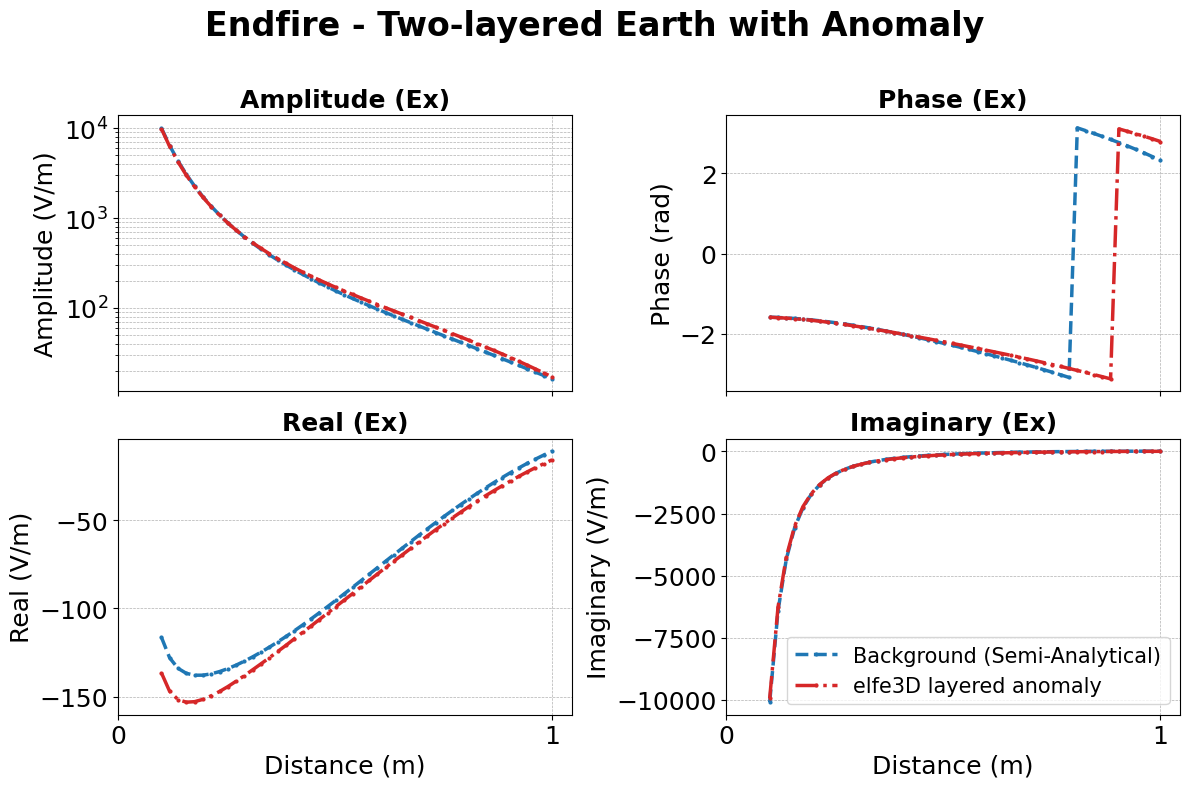

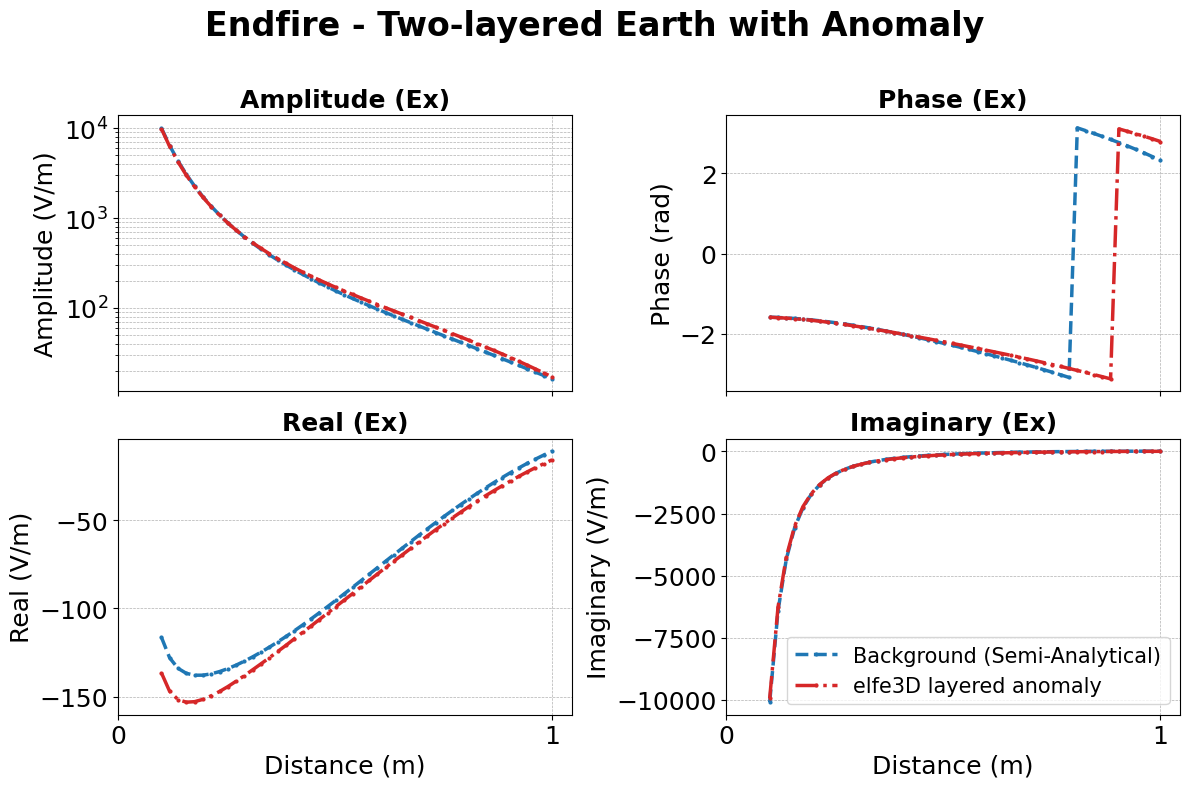

In [13]:
ReceiverLinePlot([bg, ef]).plot(suptitle="Endfire - Two-layered Earth with Anomaly")

## Anomaly response  (difference from background)

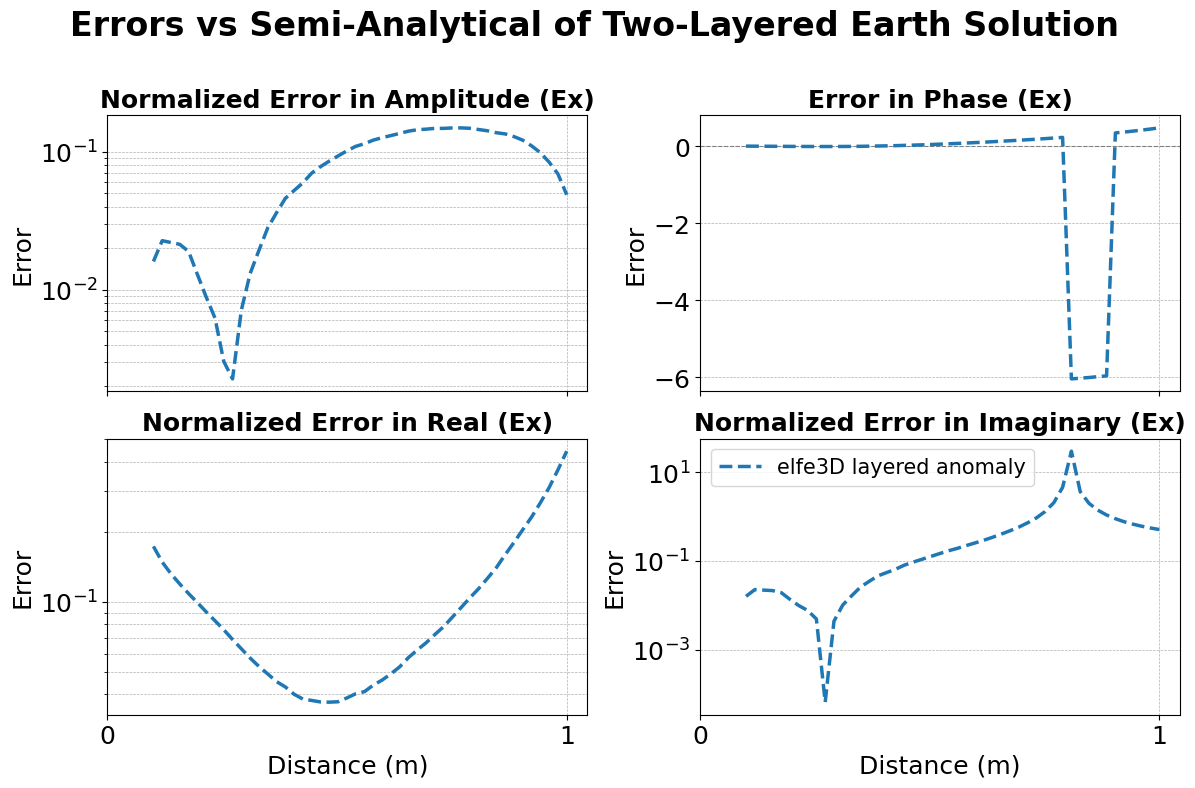

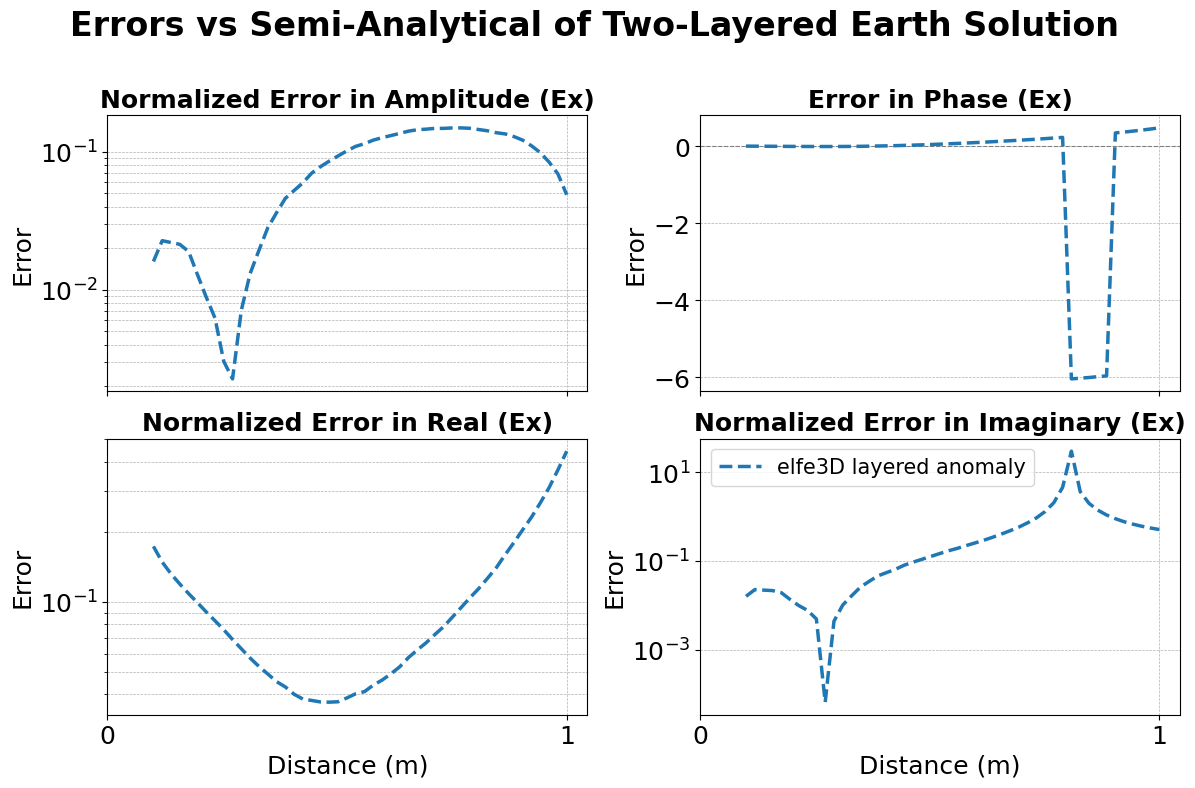

In [14]:
ReceiverLineErrorPlot([ef], reference=bg).plot(suptitle="Errors vs Semi-Analytical of Two-Layered Earth Solution")

## Combined (fields + anomaly response)

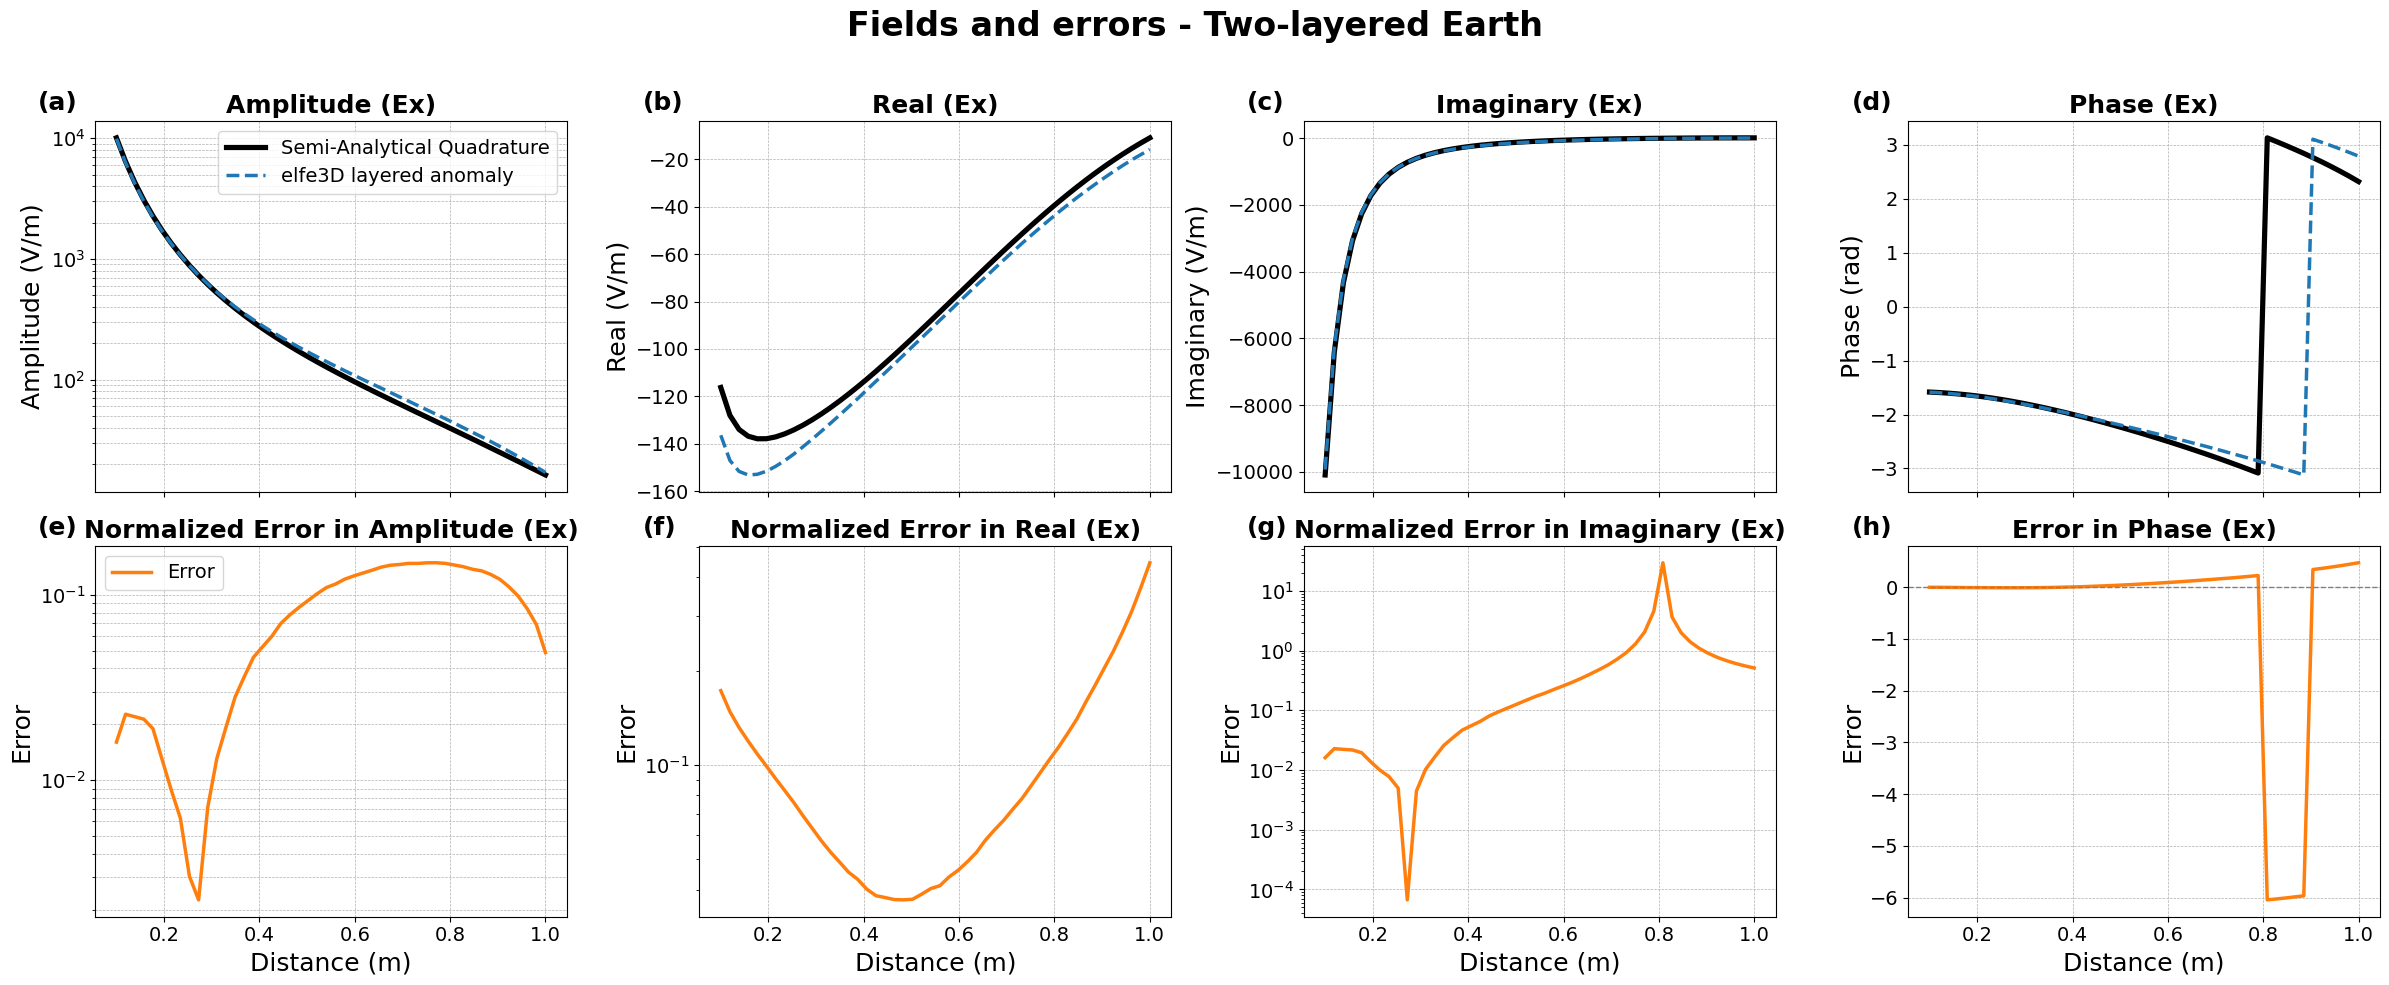

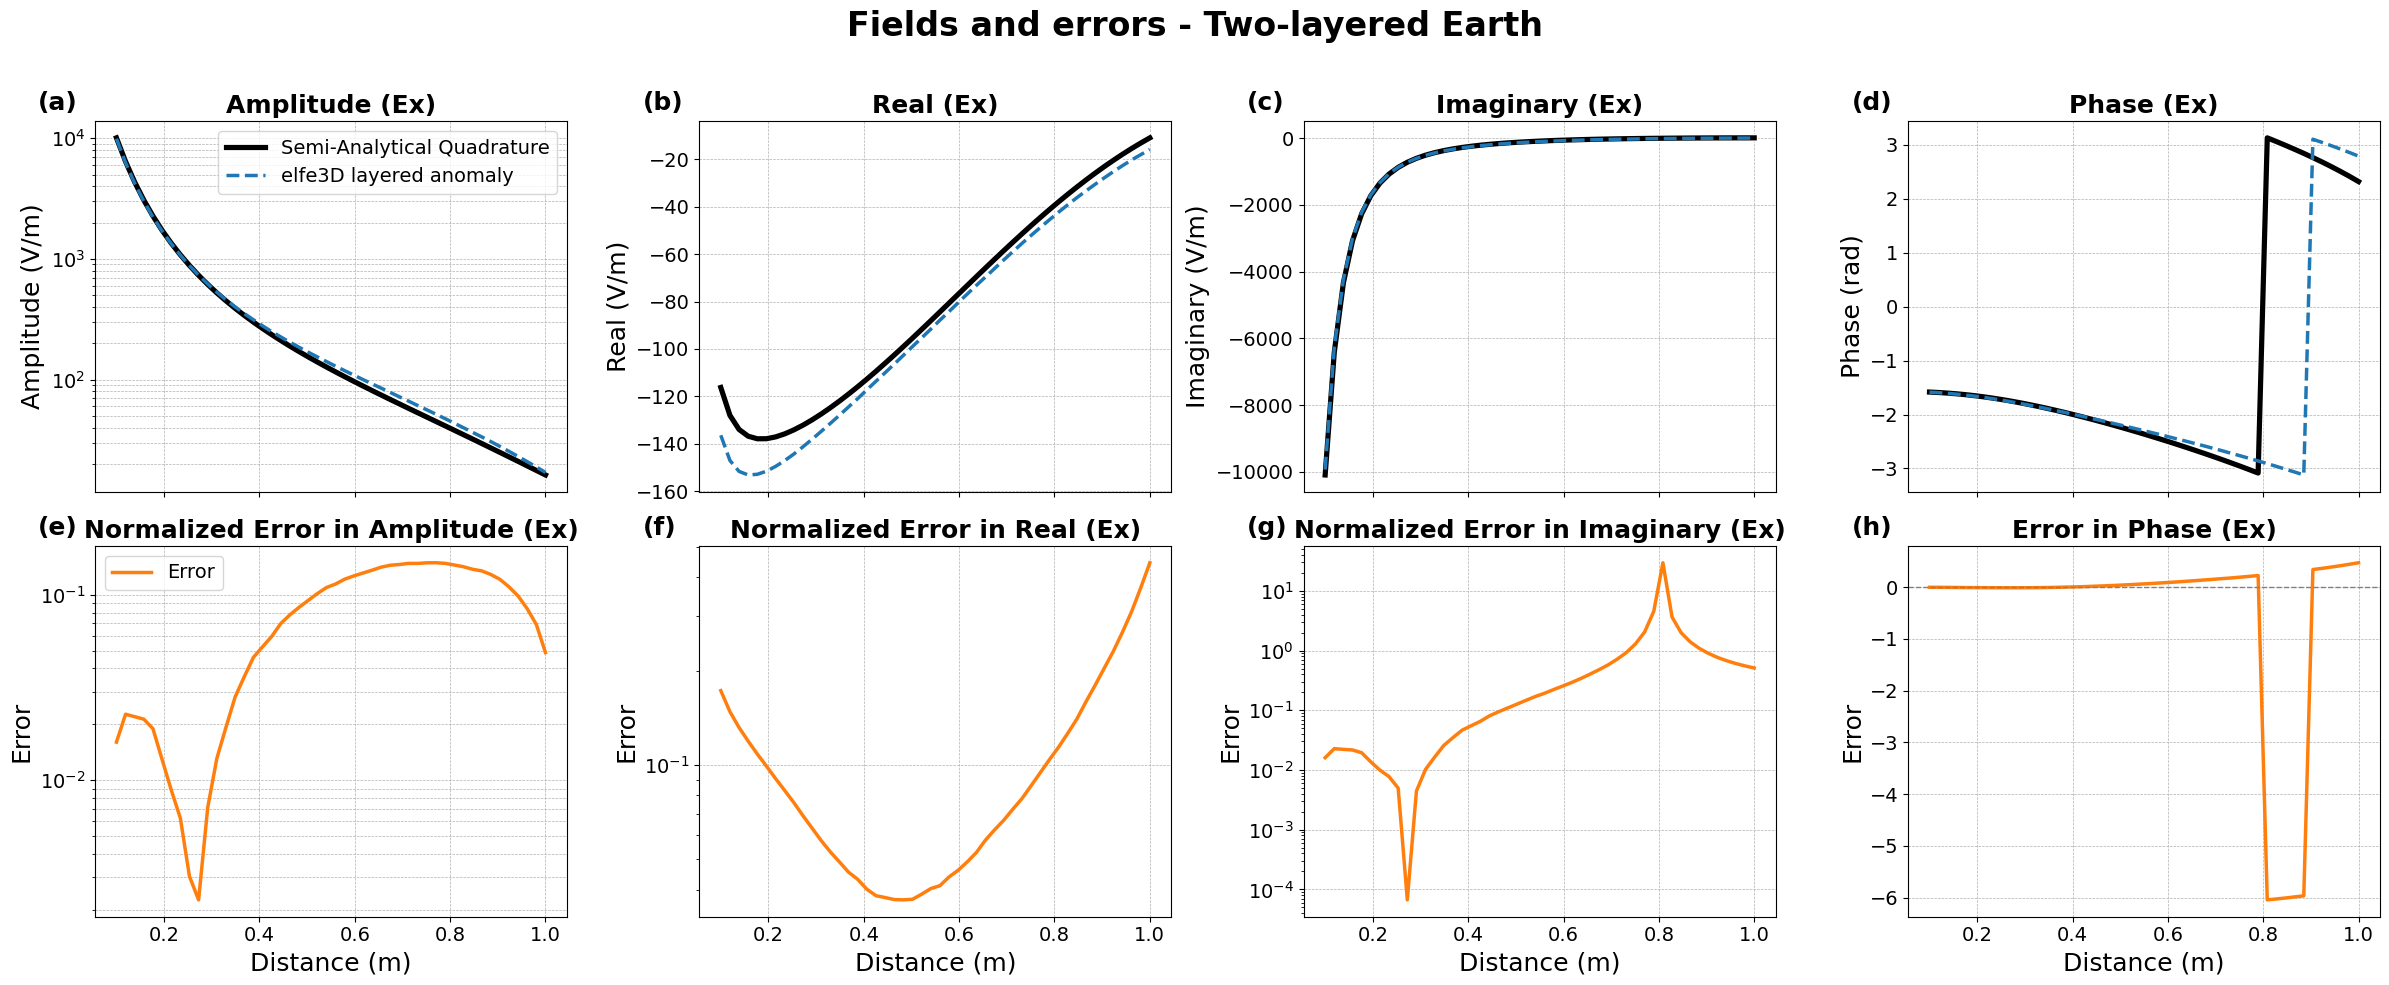

In [15]:
ReceiverLineCombined(ef, bg).plot(suptitle="Fields and errors - Two-layered Earth")

## Response distribution histogram

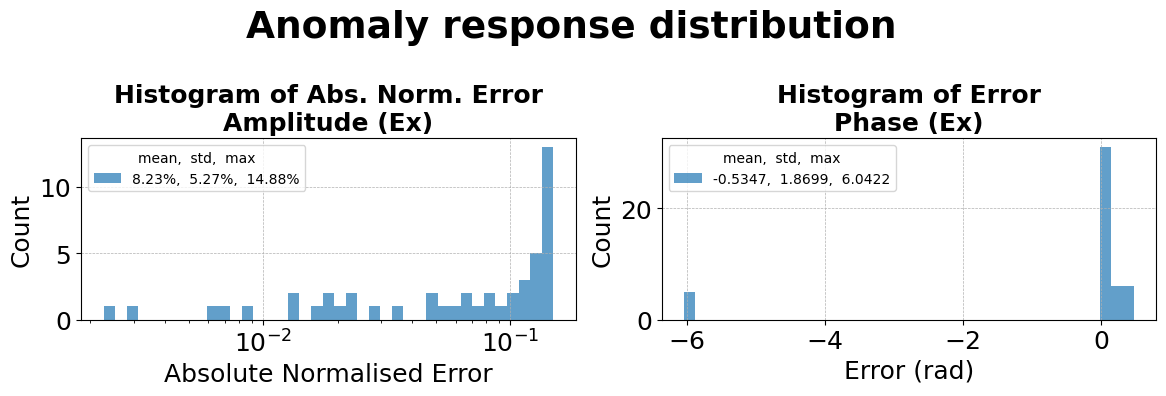

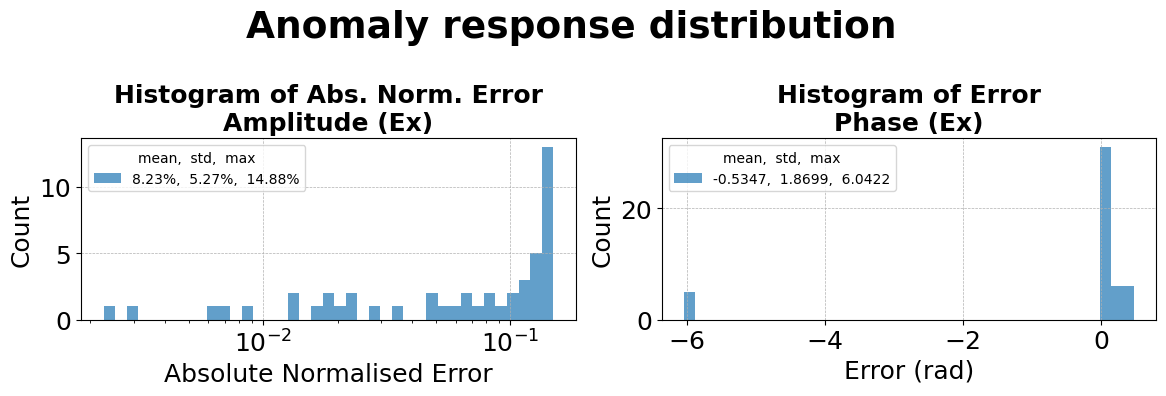

In [16]:
ErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)


## Printed anomaly response summary

In [17]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print('Anomaly response (relative to two-layer background)\n')
for qi, name in enumerate(qty_names):
    err = field_error(bg, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')


Anomaly response (relative to two-layer background)

  Amplitude   :  mean=8.230%  std=5.272%  max=14.878%
  Phase       :  mean=-0.535rad  std=1.870rad  max=6.042rad
  Real        :  mean=10.665%  std=8.876%  max=44.485%
  Imaginary   :  mean=114.670%  std=423.644%  max=2953.777%
